# 실습: Adaptive Algorithms 1 (학습률 중심)

## Adagrad & RMSProp

### 계산 실험 주제 (목표)

1. GD에서 하나의 학습률 $\eta$를 사용할 때 생기는 문제를 관찰한다.
2. 방향별 scale 차이가 큰 목적함수에서 GD, Adagrad, RMSProp의 trajectory를 비교한다.
3. Adagrad와 RMSProp의 accumulator가 어떻게 effective learning rate를 바꾸는지 확인한다.
4. DIY: 조건수(condition number), 학습률, RMSProp의 $\beta$를 바꾸며 결과를 비교한다.

---

## **주요 식: iteration update**

GD:

$$
\theta_{k+1}=\theta_k-\eta g_k
$$

Adagrad:

$$
G_{k+1}=G_k+g_k\odot g_k,
\qquad
\theta_{k+1}
=\theta_k-
\frac{\eta}{\sqrt{G_{k+1}}+\varepsilon}\odot g_k
$$

RMSProp:

$$
v_{k+1}=\beta v_k+(1-\beta)g_k\odot g_k,
\qquad
\theta_{k+1}
=\theta_k-
\frac{\eta}{\sqrt{v_{k+1}}+\varepsilon}\odot g_k
$$

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=5, suppress=True)

# 1. 계산실험: 목적함수

계산 실험을 위해, 다음의 방향별 scale 차이가 큰 2변수 볼록 이차함수를 사용한다.

$$
f(x,y)=\frac12(x^2+a y^2)
$$

gradient 벡터:

$$
\nabla f(x,y)=\begin{pmatrix}x\\ ay\end{pmatrix}
$$

* 이어서 진행할 계산실험에서 주목할 특성: $a$가 클수록 $y$ 방향 곡률이 크고, GD에서는 zig-zag 또는 느린 수렴이 나타날 수 있다.

In [4]:
# ============================================================
# 목적함수(objective function) & gradient 벡터
# ============================================================

def f_quad(theta, a=100.0):
    x, y = theta
    return 0.5 * (x**2 + a * y**2)


def grad_quad(theta, a=100.0):
    x, y = theta
    return np.array([x, a*y], dtype=float)


def algo_gd(theta0, eta=0.03, steps=80, a=100.0):
    theta = np.array(theta0, dtype=float)
    path = [theta.copy()]
    losses = [f_quad(theta, a)]
    eff_lrs = []
    accs = []
    for k in range(steps):
        g = grad_quad(theta, a)
        theta = theta - eta * g
        path.append(theta.copy())
        losses.append(f_quad(theta, a))
        eff_lrs.append(np.array([eta, eta]))
        accs.append(np.array([np.nan, np.nan]))
    return np.array(path), np.array(losses), np.array(eff_lrs), np.array(accs)


def algo_adagrad(theta0, eta=1.0, steps=80, a=100.0, eps=1e-8):
    theta = np.array(theta0, dtype=float)
    G = np.zeros_like(theta)
    path = [theta.copy()]
    losses = [f_quad(theta, a)]
    eff_lrs = []
    accs = []
    for k in range(steps):
        g = grad_quad(theta, a)
        G = G + g*g
        effective_lr = eta / (np.sqrt(G) + eps)
        theta = theta - effective_lr * g
        path.append(theta.copy())
        losses.append(f_quad(theta, a))
        eff_lrs.append(effective_lr.copy())
        accs.append(G.copy())
    return np.array(path), np.array(losses), np.array(eff_lrs), np.array(accs)


def algo_rmsprop(theta0, eta=0.3, beta=0.9, steps=80, a=100.0, eps=1e-8):
    theta = np.array(theta0, dtype=float)
    v = np.zeros_like(theta)
    path = [theta.copy()]
    losses = [f_quad(theta, a)]
    eff_lrs = []
    accs = []
    for k in range(steps):
        g = grad_quad(theta, a)
        v = beta * v + (1-beta) * (g*g)
        effective_lr = eta / (np.sqrt(v) + eps)
        theta = theta - effective_lr * g
        path.append(theta.copy())
        losses.append(f_quad(theta, a))
        eff_lrs.append(effective_lr.copy())
        accs.append(v.copy())
    return np.array(path), np.array(losses), np.array(eff_lrs), np.array(accs)

# 2. 계산 실험: GD, Adagrad, RMSProp 비교

초기값:

$$
\theta_0=(4,1)^T
$$

목적함수:

$$
f(x,y)=\frac12(x^2+100y^2)
$$

In [5]:
# ============================================================
# 실행: algorithms
# ============================================================

a = 100.0
theta0 = np.array([4.0, 1.0])
steps = ?

path_gd, loss_gd, lr_gd, acc_gd = algo_gd(theta0, eta=0.018, steps=steps, a=a)
path_ada, loss_ada, lr_ada, acc_ada = algo_adagrad(theta0, eta=1.0, steps=steps, a=a)
path_rms, loss_rms, lr_rms, acc_rms = algo_rmsprop(theta0, eta=0.25, beta=0.9, steps=steps, a=a)

print("Final theta")
print("GD      :", path_gd[-1], "loss=", loss_gd[-1])
print("Adagrad :", path_ada[-1], "loss=", loss_ada[-1])
print("RMSProp :", path_rms[-1], "loss=", loss_rms[-1])

Final theta
GD      : [3.33561 0.10737] loss= 6.1395975928454245
Adagrad : [0.58495 0.     ] loss= 0.17108208383919105
RMSProp : [ 0.77554 -0.     ] loss= 0.3007310557691843


In [ ]:
# ============================================================
# Contour and trajectory plot
# ============================================================

x = np.linspace(-4.5, 4.5, 250)
y = np.linspace(-1.5, 1.5, 250)
X, Y = np.meshgrid(x, y)
Z = 0.5 * (X**2 + a * Y**2)

plt.figure(figsize=(8, 6))
levels = np.logspace(-2, 3, 20)
plt.contour(X, Y, Z, levels=levels)
plt.plot(path_gd[:,0], path_gd[:,1], marker='o', markersize=3, label='GD')
plt.plot(path_ada[:,0], path_ada[:,1], marker='o', markersize=3, label='Adagrad')
plt.plot(path_rms[:,0], path_rms[:,1], marker='o', markersize=3, label='RMSProp')
plt.scatter([0], [0], marker='*', s=180, label='minimizer')
plt.plot(theta0[0],theta0[1], marker='s', markersize=7, label='initial guess')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trajectory comparison on ill-conditioned quadratic')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# 비교: Loss 함숫값
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(loss_gd, label='GD')
plt.plot(loss_ada, label='Adagrad')
plt.plot(loss_rms, label='RMSProp')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Objective value')
plt.title('Loss comparison')
plt.legend()
plt.grid(True)
plt.show()

# 3. 계산 실험: Effective learning rate 확인

주목: Adagrad와 RMSProp은 각 **좌표마다 다른** effective learning rate를 사용한다.

Adagrad:

$$
\eta_{k,j}^{\text{eff}}
=
\frac{\eta}{\sqrt{G_{k,j}}+\varepsilon}
$$

RMSProp:

$$
\eta_{k,j}^{\text{eff}}
=
\frac{\eta}{\sqrt{v_{k,j}}+\varepsilon}
$$

In [ ]:
# ============================================================
# Effective learning rate plots
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(lr_ada[:,0], label='x direction')
axes[0].plot(lr_ada[:,1], label='y direction')
axes[0].set_title('Adagrad effective learning rate')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Effective learning rate')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(lr_rms[:,0], label='x direction')
axes[1].plot(lr_rms[:,1], label='y direction')
axes[1].set_title('RMSProp effective learning rate')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Effective learning rate')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Accumulator plots
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(acc_ada[:,0], label='G_x')
axes[0].plot(acc_ada[:,1], label='G_y')
axes[0].set_title('Adagrad accumulator G')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Accumulated squared gradient')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(acc_rms[:,0], label='v_x')
axes[1].plot(acc_rms[:,1], label='v_y')
axes[1].set_title('RMSProp moving average v')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Moving average of squared gradient')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 4. 손 계산 확인: Adagrad의 첫 3 step

목적함수:

$$
f(x,y)=\frac12(x^2+4y^2),\qquad \nabla f(x,y)=(x,4y)^T
$$

초기값:

$$
\theta_0=(4,2)^T
$$

Adagrad parameters:

$$
\eta=1,\qquad G_0=(0,0)^T,\qquad \varepsilon\approx 0
$$



In [ ]:
# ============================================================
# Hand calculation table for Adagrad
# ============================================================

def hand_f(theta):
    x, y = theta
    return 0.5 * (x*x + 4*y*y)

def hand_grad(theta):
    x, y = theta
    return np.array([x, 4*y], dtype=float)

eta = 1.0
eps = 1e-12
theta = np.array([4.0, 2.0])
G = np.zeros(2)

rows = []
for k in range(4):
    g = hand_grad(theta)
    G_new = G + g*g
    eff_lr = eta / (np.sqrt(G_new) + eps)
    theta_new = theta - eff_lr * g
    rows.append([k, theta.copy(), g.copy(), G_new.copy(), eff_lr.copy(), theta_new.copy(), hand_f(theta)])
    theta, G = theta_new, G_new

for row in rows:
    k, th, g, Gnew, eff, thnew, val = row
    print(f"k={k}")
    print(" theta_k      =", th)
    print(" grad         =", g)
    print(" G_{k+1}      =", Gnew)
    print(" eff_lr       =", eff)
    print(" theta_{k+1}  =", thnew)
    print(" f(theta_k)   =", val)
    print("-"*50)

# 5. 계산실험(실습) 1: 조건수 변화시키기

다음 값을 바꾸어 실험하세요.

- `a = 10`, `100`, `1000`
- `theta0 = [4, 1]`, `[4, 4]`, `[1, 4]`
- GD 학습률 `eta`

### 질문

1. $a$가 커질수록 contour 모양은 어떻게 바뀌는가?
2. GD trajectory는 어떻게 변하는가?
3. Adagrad 또는 RMSProp이 더 유리한 경우는 언제인가?

In [ ]:
# ============================================================
# Student exercise 1: change condition number
# ============================================================

a_ex = 1000.0          # TODO: 10, 100, 1000 등으로 바꾸어 보기
theta0_ex = np.array([4.0, 1.0])
steps_ex = 100

path_gd_ex, loss_gd_ex, _, _ = algo_?(theta0_ex, eta=0.0015, steps=steps_ex, a=a_ex)
path_ada_ex, loss_ada_ex, _, _ = algo_?(theta0_ex, eta=1.0, steps=steps_ex, a=a_ex)
path_rms_ex, loss_rms_ex, _, _ = algo_?(theta0_ex, eta=0.25, beta=0.9, steps=steps_ex, a=a_ex)

plt.figure(figsize=(8, 5))
plt.plot(loss_gd_ex, label='GD')
plt.plot(loss_ada_ex, label='Adagrad')
plt.plot(loss_rms_ex, label='RMSProp')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Objective value')
plt.title(f'Loss comparison when a={a_ex}')
plt.legend()
plt.grid(True)
plt.show()

# 6. 계산실험(실습) 2: Sparse feature linear regression

Adagrad는 sparse feature 문제에서 자주 이용된다. 다음과 같은 간단한 선형회귀 데이터를 만들어 보죠.

모델:

$$
y=X\theta+\epsilon
$$

특징:

  * 첫 번째 feature는 자주 등장
  * 두 번째 feature는 드물게 등장

**Adagrad가 좌표별 learning rate를 어떻게 조절하는지 확인 하기**

True theta: [ 2. -5.]
GD final: [ 1.99549 -5.00681] loss= 0.009885787420798531
Adagrad final: [ 1.99549 -5.02928] loss= 0.009840838418885061


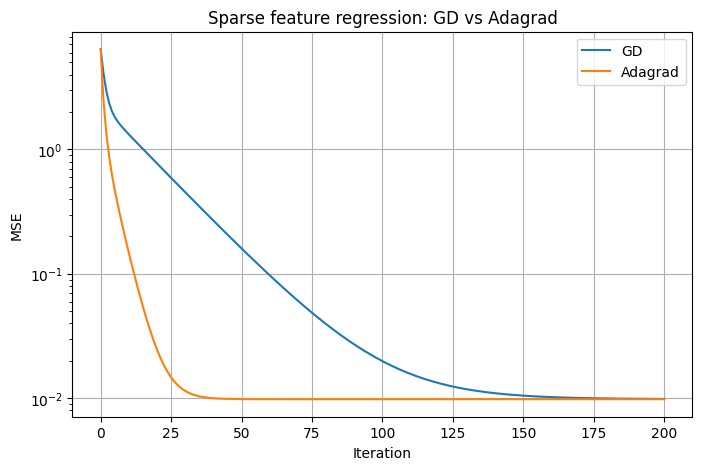

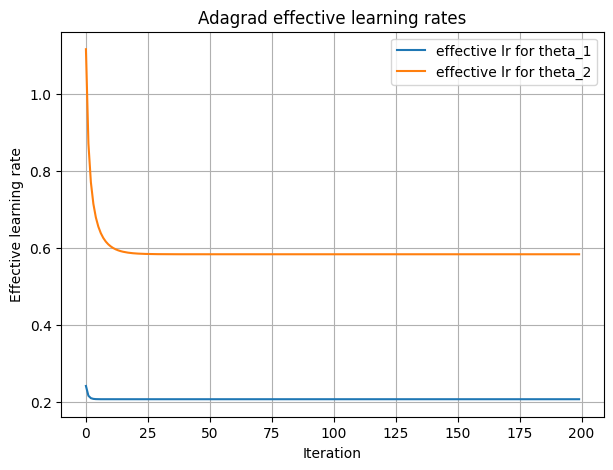

In [14]:
# ============================================================
# 계산 실습 2: sparse feature regression
# ============================================================

rng = np.random.default_rng(0)
N = 300

x1 = rng.normal(size=N)
x2 = rng.normal(size=N)
mask = rng.random(N) < 0.12   # x2 appears only in about 12% of samples
x2 = x2 * mask

X = np.column_stack([x1, x2])
theta_true = np.array([2.0, -5.0])
y = X @ theta_true + 0.1 * rng.normal(size=N)

# objective: mean squared error = (1/N)||X theta-y||^2

def mse(theta):
    r = X @ theta - y
    return np.mean(r*r)

def mse_grad(theta):
    r = X @ theta - y
    return (2/N) * X.T @ r

def run_gd_reg(theta0, eta=0.1, steps=200):
    theta = theta0.astype(float).copy()
    hist = [theta.copy()]
    losses = [mse(theta)]
    for k in range(steps):
        g = mse_grad(theta)
        theta = theta - eta*g
        hist.append(theta.copy())
        losses.append(mse(theta))
    return np.array(hist), np.array(losses)

def run_adagrad_reg(theta0, eta=1.0, steps=200, eps=1e-8):
    theta = theta0.astype(float).copy()
    G = np.zeros_like(theta)
    hist = [theta.copy()]
    losses = [mse(theta)]
    eff_hist = []
    for k in range(steps):
        g = mse_grad(theta)
        G += g*g
        eff = eta/(np.sqrt(G)+eps)
        theta = theta - eff*g
        hist.append(theta.copy())
        losses.append(mse(theta))
        eff_hist.append(eff.copy())
    return np.array(hist), np.array(losses), np.array(eff_hist)

hist_gd_reg, loss_gd_reg = run_gd_reg(np.zeros(2), eta=0.15, steps=200)
hist_ada_reg, loss_ada_reg, eff_ada_reg = run_adagrad_reg(np.zeros(2), eta=1.0, steps=200)

print('True theta:', theta_true)
print('GD final:', hist_gd_reg[-1], 'loss=', loss_gd_reg[-1])
print('Adagrad final:', hist_ada_reg[-1], 'loss=', loss_ada_reg[-1])

plt.figure(figsize=(8,5))
plt.plot(loss_gd_reg, label='GD')
plt.plot(loss_ada_reg, label='Adagrad')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Sparse feature regression: GD vs Adagrad')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(eff_ada_reg[:,0], label='effective lr for theta_1')
plt.plot(eff_ada_reg[:,1], label='effective lr for theta_2')
plt.xlabel('Iteration')
plt.ylabel('Effective learning rate')
plt.title('Adagrad effective learning rates')
plt.legend()
plt.grid(True)
plt.show()

# 7. 계산실험(실습) 3: RMSProp의 $\beta$ 바꾸기

RMSProp의 $\beta$는 과거 gradient 정보를 얼마나 오래 기억할지를 정합니다.

$$
v_{k+1}=\beta v_k+(1-\beta)g_k^2
$$

### 실험

아래 코드에서 `beta` 값을 바꾸어 보세요.

- `beta = 0.5`
- `beta = 0.9`
- `beta = 0.99`

### 질문

1. $\beta$가 커질수록 accumulator는 어떻게 변하는가?
2. effective learning rate는 더 부드럽게 변하는가?
3. 수렴 속도는 어떻게 달라지는가?

In [ ]:
# ============================================================
# Student exercise 3: beta comparison in RMSProp
# ============================================================

betas = [?, ?, ?]
plt.figure(figsize=(8,5))

for beta in betas:
    _, loss_tmp, _, _ = run_rmsprop(theta0, eta=0.25, beta=beta, steps=80, a=100.0)
    plt.plot(loss_tmp, label=f'beta={beta}')

plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Objective value')
plt.title('RMSProp beta comparison')
plt.legend()
plt.grid(True)
plt.show()